In [ ]:
#STEP 1

import pandas as pd

files = {
  "customers":"1. olist_customers_dataset.csv",
  "geolocation":"2. olist_geolocation_dataset.csv",
  "order_items":"3. olist_order_items_dataset.csv",
  "payments":"4. olist_order_payments_dataset.csv",
  "reviews":"5. olist_order_reviews_dataset.csv",
  "orders":"6. olist_orders_dataset.csv",
  "products":"7. olist_products_dataset.csv",
  "sellers":"8. olist_sellers_dataset.csv",
  "category_translation":"9. product_category_name_translation.csv"
}

dfs = {k: pd.read_csv(v) for k,v in files.items()}

summary = []
for name, df in dfs.items():
    summary.append({
        "dataset": name,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "columns": ", ".join(df.columns[:8]) + ("..." if df.shape[1] > 8 else ""),
        "possible_key": [c for c in df.columns if c.endswith("_id")][:3]
    })

pd.DataFrame(summary)


,dataset,rows,cols,columns,possible_key
0,customers,99441,5,"customer_id, customer_unique_id, customer_zip_...","[customer_id, customer_unique_id]"
1,geolocation,1000163,5,"geolocation_zip_code_prefix, geolocation_lat, ...",[]
2,order_items,112650,7,"order_id, order_item_id, product_id, seller_id...","[order_id, order_item_id, product_id]"
3,payments,103886,5,"order_id, payment_sequential, payment_type, pa...",[order_id]
4,reviews,99224,7,"review_id, order_id, review_score, review_comm...","[review_id, order_id]"
5,orders,99441,8,"order_id, customer_id, order_status, order_pur...","[order_id, customer_id]"
6,products,32951,9,"product_id, product_category_name, product_nam...",[product_id]
7,sellers,3095,4,"seller_id, seller_zip_code_prefix, seller_city...",[seller_id]
8,category_translation,71,2,"product_category_name, product_category_name_e...",[]


In [ ]:
#STEP 2
import numpy as np

quality = []
for name, df in dfs.items():
    quality.append({
        "dataset": name,
        "duplicate_rows": int(df.duplicated().sum()),
        "cols_with_nulls": int((df.isna().sum() > 0).sum()),
        "total_nulls": int(df.isna().sum().sum()),
        "top_null_cols": df.isna().sum().sort_values(ascending=False).head(3).to_dict()
    })

pd.DataFrame(quality)


,dataset,duplicate_rows,cols_with_nulls,total_nulls,top_null_cols
0,customers,0,0,0,"{'customer_id': 0, 'customer_unique_id': 0, 'c..."
1,geolocation,261831,0,0,"{'geolocation_zip_code_prefix': 0, 'geolocatio..."
2,order_items,0,0,0,"{'order_id': 0, 'order_item_id': 0, 'product_i..."
3,payments,0,0,0,"{'order_id': 0, 'payment_sequential': 0, 'paym..."
4,reviews,0,2,145903,"{'review_comment_title': 87656, 'review_commen..."
5,orders,0,3,4908,"{'order_delivered_customer_date': 2965, 'order..."
6,products,0,8,2448,"{'product_category_name': 610, 'product_descri..."
7,sellers,0,0,0,"{'seller_id': 0, 'seller_zip_code_prefix': 0, ..."
8,category_translation,0,0,0,"{'product_category_name': 0, 'product_category..."


In [ ]:
#STEP 3

clean = {}
clean_summary = []

# RULE CLEANING:
# - drop_duplicates untuk semua
# - dropna "kolom penting" (bukan semua kolom) supaya tidak buang data terlalu banyak
essential_cols = {
  "customers": None,  # tidak ada missing
  "geolocation": None,
  "order_items": None,
  "payments": ["order_id","payment_sequential","payment_type","payment_installments","payment_value"],
  "reviews": ["review_id","order_id","review_score","review_creation_date","review_answer_timestamp"],  # komentar boleh kosong
  "orders":  ["order_id","customer_id","order_status","order_purchase_timestamp","order_delivered_customer_date","order_estimated_delivery_date"],
  "products":["product_id","product_category_name"],
  "sellers": None,
  "category_translation": None
}

for name, df in dfs.items():
    before = df.shape[0]
    temp = df.drop_duplicates()

    cols = essential_cols[name]
    if cols is None:
        temp = temp.dropna()
    else:
        temp = temp.dropna(subset=cols)

    after = temp.shape[0]
    clean[name] = temp

    clean_summary.append({
        "dataset": name,
        "rows_before": before,
        "rows_after": after,
        "rows_removed": before - after
    })

clean_table = pd.DataFrame(clean_summary).sort_values("rows_removed", ascending=False)
clean_table


,dataset,rows_before,rows_after,rows_removed
1,geolocation,1000163,738332,261831
5,orders,99441,96476,2965
6,products,32951,32341,610
0,customers,99441,99441,0
2,order_items,112650,112650,0
4,reviews,99224,99224,0
3,payments,103886,103886,0
7,sellers,3095,3095,0
8,category_translation,71,71,0


In [ ]:
#STEP 4

import pandas as pd
import numpy as np

# Ambil tabel bersih (hasil Step 3)
orders = clean["orders"].copy()
customers = clean["customers"].copy()
order_items = clean["order_items"].copy()
payments = clean["payments"].copy()
reviews = clean["reviews"].copy()
products = clean["products"].copy()
sellers = clean["sellers"].copy()
category = clean["category_translation"].copy()

# Pastikan kolom tanggal jadi datetime (untuk konsistensi, meski fitur durasi baru di Step 5)
date_cols = ["order_purchase_timestamp","order_delivered_customer_date","order_estimated_delivery_date"]
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

# 1) Aggregate payments per order
payments_agg = payments.groupby("order_id", as_index=False).agg(
    payment_value_sum=("payment_value","sum"),
    payment_types_n=("payment_type","nunique"),
    payment_installments_max=("payment_installments","max")
)

# 2) Aggregate reviews per order
reviews_agg = reviews.groupby("order_id", as_index=False).agg(
    review_score_mean=("review_score","mean"),
    review_count=("review_id","nunique")
)

# 3) Produk + terjemahan kategori (ambil yang dibutuhkan saja)
products_en = products.merge(category, on="product_category_name", how="left")
products_en["product_category_name_english"] = products_en["product_category_name_english"].fillna("unknown")

# 4) Pilih kolom inti dari masing-masing tabel
orders_core = orders[[
    "order_id","customer_id","order_status",
    "order_purchase_timestamp","order_delivered_customer_date","order_estimated_delivery_date"
]]

customers_core = customers[[
    "customer_id","customer_unique_id","customer_city","customer_state"
]]

order_items_core = order_items[[
    "order_id","order_item_id","product_id","seller_id","price","freight_value"
]]

products_core = products_en[[
    "product_id","product_category_name_english"
]]

sellers_core = sellers[[
    "seller_id","seller_city","seller_state"
]]

# 5) JOIN menjadi 1 tabel integrasi (grain: item-level)
df_int = orders_core.merge(customers_core, on="customer_id", how="left")
df_int = df_int.merge(order_items_core, on="order_id", how="left")
df_int = df_int.merge(products_core, on="product_id", how="left")
df_int = df_int.merge(sellers_core, on="seller_id", how="left")
df_int = df_int.merge(payments_agg, on="order_id", how="left")
df_int = df_int.merge(reviews_agg, on="order_id", how="left")

# 6) Output tabel ringkasan integrasi (buat laporan)
integration_summary = pd.DataFrame([{
    "final_rows": df_int.shape[0],
    "final_cols": df_int.shape[1],
    "unique_orders": df_int["order_id"].nunique(),
    "orders_without_items": int(df_int.groupby("order_id")["order_item_id"].apply(lambda s: s.isna().all()).sum())
}])
integration_summary


,final_rows,final_cols,unique_orders,orders_without_items
0,110196,22,96476,0


In [ ]:
#STEP 4

import pandas as pd
import numpy as np

# Ambil tabel bersih (hasil Step 3)
orders = clean["orders"].copy()
customers = clean["customers"].copy()
order_items = clean["order_items"].copy()
payments = clean["payments"].copy()
reviews = clean["reviews"].copy()
products = clean["products"].copy()
sellers = clean["sellers"].copy()
category = clean["category_translation"].copy()

# Pastikan kolom tanggal jadi datetime (untuk konsistensi, meski fitur durasi baru di Step 5)
date_cols = ["order_purchase_timestamp","order_delivered_customer_date","order_estimated_delivery_date"]
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

# 1) Aggregate payments per order
payments_agg = payments.groupby("order_id", as_index=False).agg(
    payment_value_sum=("payment_value","sum"),
    payment_types_n=("payment_type","nunique"),
    payment_installments_max=("payment_installments","max")
)

# 2) Aggregate reviews per order
reviews_agg = reviews.groupby("order_id", as_index=False).agg(
    review_score_mean=("review_score","mean"),
    review_count=("review_id","nunique")
)

# 3) Produk + terjemahan kategori (ambil yang dibutuhkan saja)
products_en = products.merge(category, on="product_category_name", how="left")
products_en["product_category_name_english"] = products_en["product_category_name_english"].fillna("unknown")

# 4) Pilih kolom inti dari masing-masing tabel
orders_core = orders[[
    "order_id","customer_id","order_status",
    "order_purchase_timestamp","order_delivered_customer_date","order_estimated_delivery_date"
]]

customers_core = customers[[
    "customer_id","customer_unique_id","customer_city","customer_state"
]]

order_items_core = order_items[[
    "order_id","order_item_id","product_id","seller_id","price","freight_value"
]]

products_core = products_en[[
    "product_id","product_category_name_english"
]]

sellers_core = sellers[[
    "seller_id","seller_city","seller_state"
]]

# 5) JOIN menjadi 1 tabel integrasi (grain: item-level)
df_int = orders_core.merge(customers_core, on="customer_id", how="left")
df_int = df_int.merge(order_items_core, on="order_id", how="left")
df_int = df_int.merge(products_core, on="product_id", how="left")
df_int = df_int.merge(sellers_core, on="seller_id", how="left")
df_int = df_int.merge(payments_agg, on="order_id", how="left")
df_int = df_int.merge(reviews_agg, on="order_id", how="left")

# 6) Output tabel ringkasan integrasi (buat laporan)
integration_summary = pd.DataFrame([{
    "final_rows": df_int.shape[0],
    "final_cols": df_int.shape[1],
    "unique_orders": df_int["order_id"].nunique(),
    "orders_without_items": int(df_int.groupby("order_id")["order_item_id"].apply(lambda s: s.isna().all()).sum())
}])
df_int.sample(20, random_state=42)

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,order_item_id,...,price,freight_value,product_category_name_english,seller_city,seller_state,payment_value_sum,payment_types_n,payment_installments_max,review_score_mean,review_count
89830,12701d216c208b08132694d01af602a7,39351277fa612e0c7ac8077f7ac038d3,delivered,2018-04-07 23:57:34,2018-04-11 21:06:59,2018-04-25,9613205127b4837f2210caee34d05e41,maua,SP,1,...,59.99,8.88,health_beauty,santo andre,SP,68.87,1.0,2.0,5.0,1.0
15725,99ca85d0497f1b958fabcd12b46168e6,f61b744f032d3de6c01387227322b865,delivered,2017-10-15 14:31:50,2017-10-23 17:20:03,2017-11-10,ba9092f02be0cdd12bc6660489fdc700,nazareno,MG,1,...,31.90,12.48,computers_accessories,belo horizonte,MG,44.38,1.0,4.0,5.0,1.0
92222,fb415a86a28d4698a9be26d2e871d31c,7087346b1fd0a0ab1ee23d86b692b132,delivered,2017-10-16 21:57:17,2017-11-03 22:03:45,2017-11-17,7422f971f7ad3d66445f8dc98fccc469,salvador,BA,1,...,550.00,135.40,health_beauty,sao paulo,SP,685.40,1.0,8.0,5.0,1.0
28601,46d941280fb05532830575927a3530f4,a116f93563fbdf7029e5cad149c8e0ee,delivered,2018-01-19 16:33:55,2018-02-14 23:54:59,2018-03-01,be9216b264ae917bff124671d6ca81ed,casa nova,BA,1,...,94.90,19.90,sports_leisure,borda da mata,MG,114.80,1.0,1.0,5.0,1.0
76504,3e22c141d2861860889375c6fd7b89b3,afecd87de20b72ea2bac4b7cdfe977f3,delivered,2018-01-21 12:16:51,2018-02-08 20:26:52,2018-02-26,dfbcc41e559a4afae12abf5adfa17c6a,pacajus,CE,1,...,69.90,27.12,bed_bath_table,ibitinga,SP,220.14,1.0,8.0,4.0,1.0
36238,cc2f534a432b33d1e7e67204ab44f662,db969fad91c6771c8617e1a89aa6d810,delivered,2018-07-28 23:32:39,2018-08-14 17:21:27,2018-08-30,da3258a80458be49ca080428f6b88a25,porto seguro,BA,1,...,69.99,27.44,art,salto,SP,97.43,1.0,1.0,3.0,1.0
72157,6eafb3047f5d0c7cadeec9d129f0e4d0,40915d2aa40e340e13b8635cf59048d3,delivered,2018-08-26 21:55:14,2018-08-30 01:41:43,2018-09-06,9858c785781f08bd45191d685e5034f3,alvorada,RS,1,...,199.00,12.88,cool_stuff,montenegro,RS,211.88,1.0,15.0,5.0,1.0
106166,6ae532533e1496cc176aa74fee5aa9bf,1c79e6c28df5dbb32fb4b484b0ae350b,delivered,2017-11-29 21:46:31,2018-01-12 00:58:52,2017-12-26,35dd02aa966dc8f3f5d2277e0cb8fff9,campos dos goytacazes,RJ,1,...,79.90,15.31,fashion_underwear_beach,sao paulo,SP,95.21,1.0,9.0,1.0,1.0
6329,0d24d62857c1f2d00801a3512dce5d1f,4eba4e54a08ee98d9031561c10c499c5,delivered,2018-07-19 10:49:10,2018-07-26 12:46:54,2018-08-10,e261dace2d1fe8f854e1597b9e507d31,navirai,MS,2,...,43.00,18.40,sports_leisure,praia grande,SP,122.80,1.0,1.0,5.0,1.0
35290,b282dff26b02dc8eb8715aa5996b13a0,b7afc661f446c22413d9f3e0c1b5aeed,delivered,2018-04-05 07:41:46,2018-04-12 12:42:53,2018-04-19,19f276173a56972adf05f21e789773fe,sao paulo,SP,1,...,110.80,11.40,sports_leisure,sao paulo,SP,122.20,1.0,1.0,5.0,1.0


In [ ]:
#STEP 5

import numpy as np

# Copy dataset integrasi
df_final = df_int.copy()

# Feature 1: total nilai item
df_final["total_item_value"] = df_final["price"] + df_final["freight_value"]

# Feature 2: durasi delivery (hari)
df_final["delivery_duration_days"] = (
    df_final["order_delivered_customer_date"]
    - df_final["order_purchase_timestamp"]
).dt.days

# Feature 3: apakah telat
df_final["is_late_delivery"] = np.where(
    df_final["order_delivered_customer_date"]
    > df_final["order_estimated_delivery_date"],
    1,
    0
)

# Feature 4: sentimen dari review score
df_final["review_sentiment"] = np.where(
    df_final["review_score_mean"] >= 4,
    "Positive",
    np.where(df_final["review_score_mean"] <= 2, "Negative", "Neutral")
)

# OUTPUT: tampilkan tabel join detail dengan fitur baru
df_final.sample(20, random_state=42)



,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,order_item_id,...,seller_state,payment_value_sum,payment_types_n,payment_installments_max,review_score_mean,review_count,total_item_value,delivery_duration_days,is_late_delivery,review_sentiment
89830,12701d216c208b08132694d01af602a7,39351277fa612e0c7ac8077f7ac038d3,delivered,2018-04-07 23:57:34,2018-04-11 21:06:59,2018-04-25,9613205127b4837f2210caee34d05e41,maua,SP,1,...,SP,68.87,1.0,2.0,5.0,1.0,68.87,3,0,Positive
15725,99ca85d0497f1b958fabcd12b46168e6,f61b744f032d3de6c01387227322b865,delivered,2017-10-15 14:31:50,2017-10-23 17:20:03,2017-11-10,ba9092f02be0cdd12bc6660489fdc700,nazareno,MG,1,...,MG,44.38,1.0,4.0,5.0,1.0,44.38,8,0,Positive
92222,fb415a86a28d4698a9be26d2e871d31c,7087346b1fd0a0ab1ee23d86b692b132,delivered,2017-10-16 21:57:17,2017-11-03 22:03:45,2017-11-17,7422f971f7ad3d66445f8dc98fccc469,salvador,BA,1,...,SP,685.40,1.0,8.0,5.0,1.0,685.40,18,0,Positive
28601,46d941280fb05532830575927a3530f4,a116f93563fbdf7029e5cad149c8e0ee,delivered,2018-01-19 16:33:55,2018-02-14 23:54:59,2018-03-01,be9216b264ae917bff124671d6ca81ed,casa nova,BA,1,...,MG,114.80,1.0,1.0,5.0,1.0,114.80,26,0,Positive
76504,3e22c141d2861860889375c6fd7b89b3,afecd87de20b72ea2bac4b7cdfe977f3,delivered,2018-01-21 12:16:51,2018-02-08 20:26:52,2018-02-26,dfbcc41e559a4afae12abf5adfa17c6a,pacajus,CE,1,...,SP,220.14,1.0,8.0,4.0,1.0,97.02,18,0,Positive
36238,cc2f534a432b33d1e7e67204ab44f662,db969fad91c6771c8617e1a89aa6d810,delivered,2018-07-28 23:32:39,2018-08-14 17:21:27,2018-08-30,da3258a80458be49ca080428f6b88a25,porto seguro,BA,1,...,SP,97.43,1.0,1.0,3.0,1.0,97.43,16,0,Neutral
72157,6eafb3047f5d0c7cadeec9d129f0e4d0,40915d2aa40e340e13b8635cf59048d3,delivered,2018-08-26 21:55:14,2018-08-30 01:41:43,2018-09-06,9858c785781f08bd45191d685e5034f3,alvorada,RS,1,...,RS,211.88,1.0,15.0,5.0,1.0,211.88,3,0,Positive
106166,6ae532533e1496cc176aa74fee5aa9bf,1c79e6c28df5dbb32fb4b484b0ae350b,delivered,2017-11-29 21:46:31,2018-01-12 00:58:52,2017-12-26,35dd02aa966dc8f3f5d2277e0cb8fff9,campos dos goytacazes,RJ,1,...,SP,95.21,1.0,9.0,1.0,1.0,95.21,43,1,Negative
6329,0d24d62857c1f2d00801a3512dce5d1f,4eba4e54a08ee98d9031561c10c499c5,delivered,2018-07-19 10:49:10,2018-07-26 12:46:54,2018-08-10,e261dace2d1fe8f854e1597b9e507d31,navirai,MS,2,...,SP,122.80,1.0,1.0,5.0,1.0,61.40,7,0,Positive
35290,b282dff26b02dc8eb8715aa5996b13a0,b7afc661f446c22413d9f3e0c1b5aeed,delivered,2018-04-05 07:41:46,2018-04-12 12:42:53,2018-04-19,19f276173a56972adf05f21e789773fe,sao paulo,SP,1,...,SP,122.20,1.0,1.0,5.0,1.0,122.20,7,0,Positive


In [ ]:
#STEP 6

import pandas as pd
import numpy as np

# Pastikan pakai dataset terbaru dari Step 5
# df_final harus sudah ada (hasil dari df_int.copy() + fitur)
required_cols = ["order_id", "order_item_id", "total_item_value", "payment_value_sum"]
missing = [c for c in required_cols if c not in df_final.columns]
if missing:
    raise ValueError(f"Kolom ini belum ada di df_final: {missing}. Pastikan Step 4 & 5 sudah jalan.")

# Aggregasi per order untuk validasi
val = df_final.groupby("order_id", as_index=False).agg(
    item_sales_sum=("total_item_value", "sum"),
    items_n=("order_item_id", "count"),
    payment_value_sum=("payment_value_sum", "first")
)

# Kalau payment_value_sum masih ada NaN, isi 0 biar aman (atau bisa drop)
val["payment_value_sum"] = val["payment_value_sum"].fillna(0)

# Selisih pembayaran vs total item sales
val["diff_payment_vs_items"] = val["payment_value_sum"] - val["item_sales_sum"]

# Tabel output validasi (yang diminta dosen)
validation_table = pd.DataFrame([
    ["Total order unik", df_final["order_id"].nunique()],
    ["Order dengan item", int((val["items_n"] > 0).sum())],
    ["Order tanpa item", int((val["items_n"] == 0).sum())],
    ["Total item sales", round(val["item_sales_sum"].sum(), 2)],
    ["Total payment", round(val["payment_value_sum"].sum(), 2)],
    ["Mean abs diff", round(val["diff_payment_vs_items"].abs().mean(), 4)],
    ["Median abs diff", round(val["diff_payment_vs_items"].abs().median(), 4)],
    ["% abs diff <= 1", round((val["diff_payment_vs_items"].abs() <= 1).mean() * 100, 2)]
], columns=["metric", "value"])

validation_table



,metric,value
0,Total order unik,9.647600e+04
1,Order dengan item,9.647600e+04
2,Order tanpa item,0.000000e+00
3,Total item sales,1.541914e+07
4,Total payment,1.542183e+07
5,Mean abs diff,3.500000e-02
6,Median abs diff,0.000000e+00
7,% abs diff <= 1,9.974000e+01


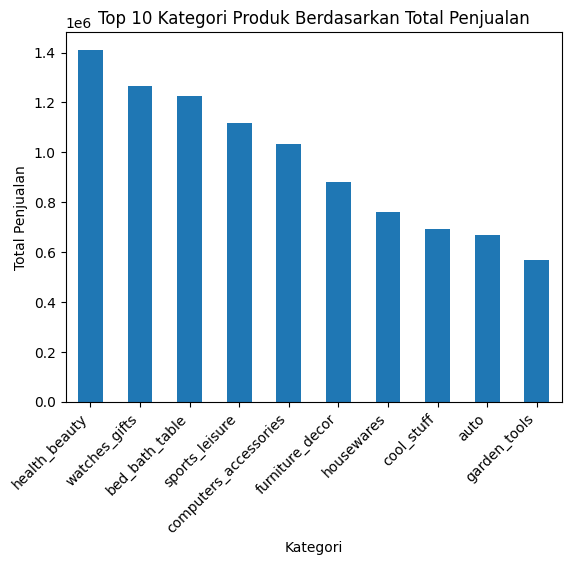

In [ ]:
#STEP 7

import matplotlib.pyplot as plt
import pandas as pd

# Safety check
needed = ["product_category_name_english", "total_item_value"]
miss = [c for c in needed if c not in df_final.columns]
if miss:
    raise ValueError(f"Kolom ini belum ada di df_final: {miss}. Pastikan Step 4-5 sudah dijalankan.")

top_category = (
    df_final.groupby("product_category_name_english", dropna=False)["total_item_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_category

top_category.set_index("product_category_name_english")["total_item_value"].plot(kind="bar")
plt.title("Top 10 Kategori Produk Berdasarkan Total Penjualan")
plt.xlabel("Kategori")
plt.ylabel("Total Penjualan")
plt.xticks(rotation=45, ha="right")
plt.show()


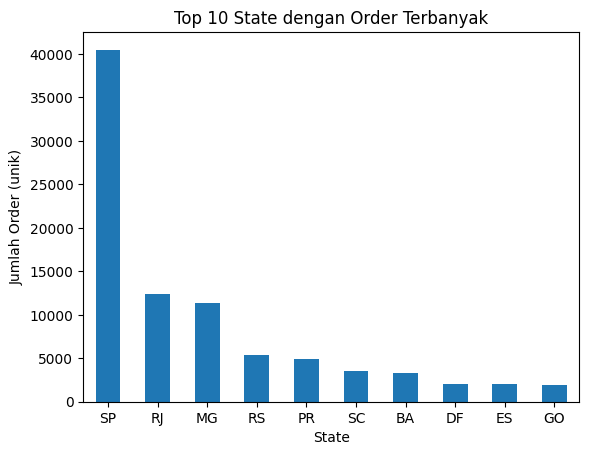

In [ ]:
#STEP 7

top_states = (
    df_final.groupby("customer_state")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"order_id":"total_orders"})
)

top_states

top_states.set_index("customer_state")["total_orders"].plot(kind="bar")
plt.title("Top 10 State dengan Order Terbanyak")
plt.xlabel("State")
plt.ylabel("Jumlah Order (unik)")
plt.xticks(rotation=0)
plt.show()


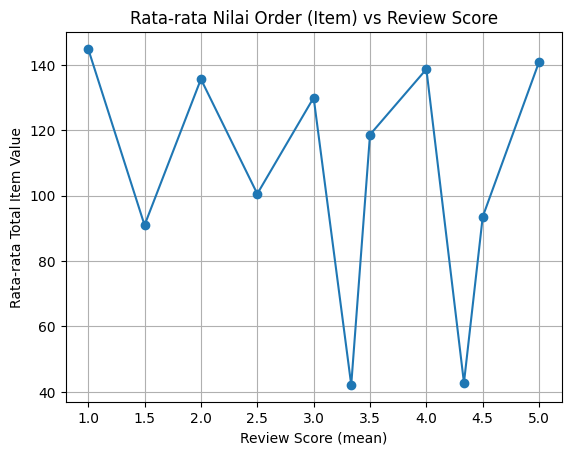

In [ ]:
#STEP 7

rating_vs_value = (
    df_final.groupby("review_score_mean")["total_item_value"]
    .mean()
    .reset_index()
    .sort_values("review_score_mean")
)

rating_vs_value

plt.plot(rating_vs_value["review_score_mean"], rating_vs_value["total_item_value"], marker="o")
plt.title("Rata-rata Nilai Order (Item) vs Review Score")
plt.xlabel("Review Score (mean)")
plt.ylabel("Rata-rata Total Item Value")
plt.grid(True)
plt.show()

